In [20]:
from cifar10_web import cifar10
from matplotlib import pyplot as plt

import numpy as np

import torch.nn as nn
import torch
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
# from kornia.filters import UnsharpMask


from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


import warnings 
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")



In [14]:
X_train, train_labels, X_test, test_labels = cifar10(path=None)

X_train = X_train.reshape(-1,3,32,32)
X_test = X_test.reshape(-1,3,32,32)

mean = X_train.mean(axis=(0,2,3)).reshape(1,3,1,1)
std = X_train.std(axis=(0,2,3)).reshape(1,3,1,1)

X_train = (X_train - mean) / std 
X_test = (X_test - mean) /std 

X_train_noisy = X_train + np.random.randn(*X_train.shape)*0.2
X_test_noisy = X_test + np.random.randn(*X_test.shape)*0.2

X_train, X_test, X_train_noisy, X_test_noisy = map(torch.tensor, [X_train, X_test, X_train_noisy, X_test_noisy])

# X_train, X_test, X_train_noisy, X_test_noisy = map(lambda x:x.to(device), [X_train, X_test, X_train_noisy, X_test_noisy])


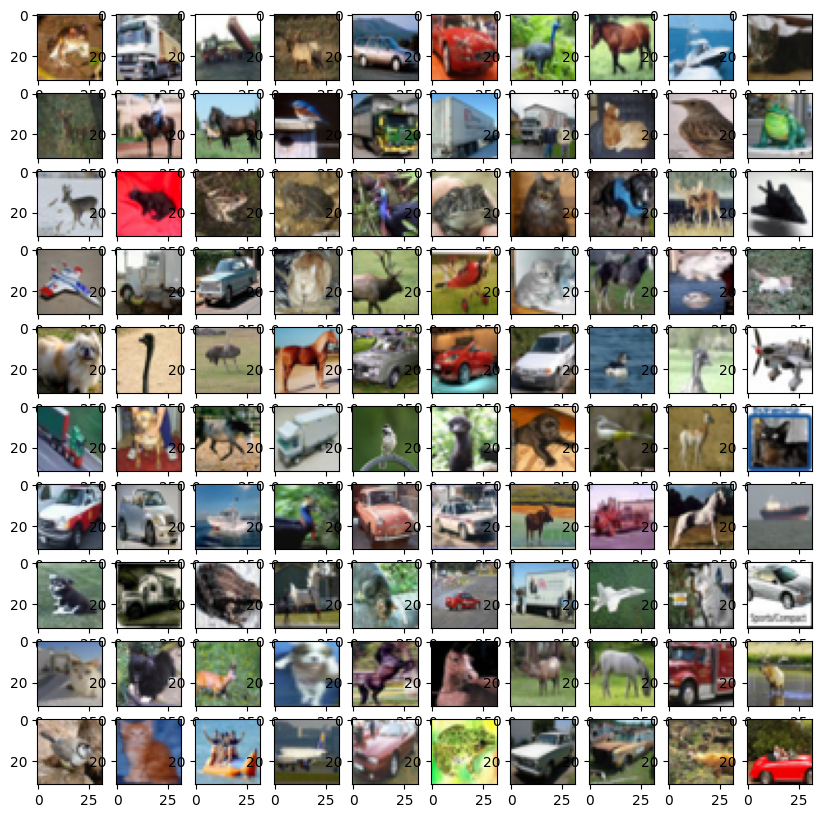

In [23]:
# _imgs = image_format(model(X_test[:100].to(device)))

plt.figure(figsize=(10,10))
for _imgid in range(100):
    plt.subplot(10,10,_imgid+1)    

    # plt.subplot(1,3,1)
    # plt.imshow(image_format(X_test[_imgid].reshape(1,3,32,32))[0])

    # plt.subplot(1,3,2)
    plt.imshow(image_format(X_train[_imgid].reshape(1,3,32,32))[0])

    # plt.subplot(10,3,3)
    # plt.imshow(imgs[_imgid]/imgs[_imgid].max())
plt.show()

In [15]:
def image_format(img):
    img  = img.detach().cpu().numpy()
    img = img.transpose(0,2,3,1)
    img = img * std.reshape(1,1,1,3)
    img = img + mean.reshape(1,1,1,3)
    return img

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.11838694141440831..1.0662715066678823].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.09015405015008948..1.1131382931270863].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.03722512937847855..1.1675281016768047].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.05017176721640393..0.9953699752725238].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.12538264800143228..1.0780115153065597].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.07305067161423073..1.0311930612078037].
Clipping input d

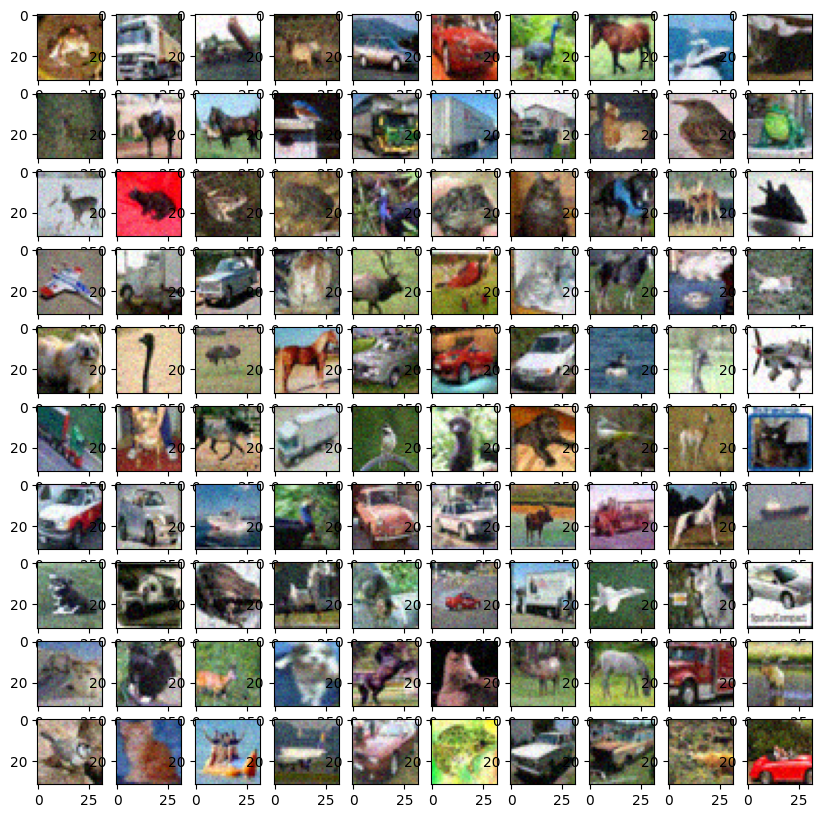

In [24]:
# _imgs = image_format(model(X_test[:100].to(device)))

plt.figure(figsize=(10,10))
for _imgid in range(100):
    plt.subplot(10,10,_imgid+1)    

    # plt.subplot(1,3,1)
    # plt.imshow(image_format(X_test[_imgid].reshape(1,3,32,32))[0])

    # plt.subplot(1,3,2)
    plt.imshow(image_format(X_train_noisy[_imgid].reshape(1,3,32,32))[0])

    # plt.subplot(10,3,3)
    # plt.imshow(imgs[_imgid]/imgs[_imgid].max())
plt.show()

In [7]:
encoder = nn.Sequential(
    nn.Conv2d(in_channels=3, out_channels=100, kernel_size=2),
    nn.ReLU(),
    # nn.MaxPool2d(kernel_size=2),

    nn.Conv2d(in_channels=100, out_channels=100, kernel_size=2),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),

    nn.Conv2d(in_channels=100, out_channels=100, kernel_size=2),
    nn.ReLU(),
    # nn.MaxPool2d(kernel_size=2),

    nn.Conv2d(in_channels=100, out_channels=100, kernel_size=2),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),

    nn.Flatten(),
    nn.Linear(100*6*6, 100*6*6),
    nn.Unflatten(1,(100,6,6))



)

decoder = nn.Sequential(
    nn.ConvTranspose2d(in_channels=100, out_channels=100, kernel_size=2),
    nn.ReLU(),
    # nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),


    nn.ConvTranspose2d(in_channels=100, out_channels=50, kernel_size=2),
    nn.ReLU(),
    # nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),

    nn.ConvTranspose2d(in_channels=50, out_channels=50, kernel_size=2),
    nn.ReLU(),

    nn.ConvTranspose2d(in_channels=50, out_channels=50, kernel_size=3),
    nn.ReLU(),


    nn.ConvTranspose2d(in_channels=50, out_channels=50, kernel_size=3),
    nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),

    nn.ReLU(),

    nn.ConvTranspose2d(in_channels=50, out_channels=50, kernel_size=2),
    nn.ReLU(),


    nn.ConvTranspose2d(in_channels=50, out_channels=50, kernel_size=2),
    nn.ReLU(),

    nn.ConvTranspose2d(in_channels=50, out_channels=50, kernel_size=2),
    nn.ReLU(),
    # UnsharpMask(kernel_size=5, sigma=(1.0, 1.0)),


    nn.ConvTranspose2d(in_channels=50, out_channels=50, kernel_size=2),
    nn.ReLU(),

    nn.ConvTranspose2d(in_channels=50, out_channels=50, kernel_size=2),
    nn.ReLU(),

    nn.ConvTranspose2d(in_channels=50, out_channels=3, kernel_size=2),
    # UnsharpMask(kernel_size=5, sigma=(1.0, 1.0))


    # nn.Flatten(),
    # nn.Linear(3*32*32, 3*32*32),
    # nn.Unflatten(1,(3,32,32)),
    nn.Tanh()
)


model = nn.Sequential(encoder,decoder).to(device)
model = torch.compile(model)
print(encoder(X_test[:17].to(device)).shape)
print(model(X_test[:17].to(device)).shape)

torch.Size([17, 100, 6, 6])
torch.Size([17, 3, 32, 32])


In [8]:
lossfn = nn.MSELoss()

optimizer = optim.Adam(model.parameters(), lr=1e-3, amsgrad=True,decoupled_weight_decay=1e-3)

dataset = TensorDataset(X_train_noisy, X_train)
train_loader = DataLoader(dataset, batch_size=700, shuffle=True)

In [9]:
epochs = 30
pbar = tqdm(range(epochs), ncols=90, colour="green")

for _ in pbar:
    for Xtnb, Xtb in train_loader:
        Xtnb, Xtb = Xtnb.to(device), Xtb.to(device)
        X_hat = model(Xtb)
        loss = lossfn(X_hat, Xtb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        pbar.set_postfix_str(f"loss: {loss*100:.1f}%")


100%|████████████████████████████████████████| 30/30 [05:19<00:00, 10.65s/it, loss: 20.2%]


In [12]:
optimizer2 = optim.Adam(model.parameters(), lr=1e-4,amsgrad=True)#,weight_decay=1e-5)
epochs2 = 30
pbar2 = tqdm(range(epochs2), ncols=90, colour="green")

for _ in pbar2:
    for Xtnb2, Xtb2 in train_loader:
        Xtnb2, Xtb2 = Xtnb2.to(device), Xtb2.to(device)
        X_hat2 = model(Xtb2)
        loss2 = lossfn(X_hat2, Xtb2)
        optimizer2.zero_grad()
        loss2.backward()
        optimizer2.step()

        pbar2.set_postfix_str(f"loss: {loss2*100:.1f}%")


 47%|██████████████████▋                     | 14/30 [02:36<02:58, 11.18s/it, loss: 19.0%]


KeyboardInterrupt: 

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.02597038040620786..1.059180848255684].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.15081130649416918..1.0497362670898696].


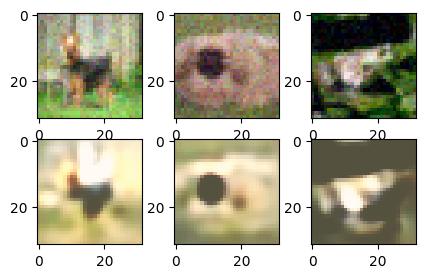

In [54]:
_imgs = image_format(model(X_test[:100].to(device)))

_idx = np.random.randint(100,size=3)

plt.figure(figsize=(5,3))
for _imgid,_id in zip(_idx,range(3)):
    plt.subplot(2,3,_id+1)    
    plt.imshow(image_format(X_test_noisy[_imgid].reshape(1,3,32,32))[0])

    plt.subplot(2,3,_id+3+1)
    plt.imshow(_imgs[_imgid]/_imgs[_imgid].max())
plt.show()

In [ ]:
_imgs = image_format(model(X_test[:100].to(device)))

_idx = np.random.randint(100,size=3)

plt.figure(figsize=(10,5))
for _imgid,_id in zip(_idx,range(50)):
    plt.subplot(2,3,_id+1)    
    plt.imshow(image_format(X_test_noisy[_imgid].reshape(1,3,32,32))[0])

    plt.subplot(2,3,_id+3+1)
    plt.imshow(_imgs[_imgid]/_imgs[_imgid].max())
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0904882754400701..1.16337421771785].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.032392919315675284..0.9033221520182722].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0007179184354448864..1.0790671491720034].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.13649148746520845..1.013683784785104].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.056269087145382646..1.1067052788143739].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.1899515471972461..1.147089036970334].
Clipping input data t

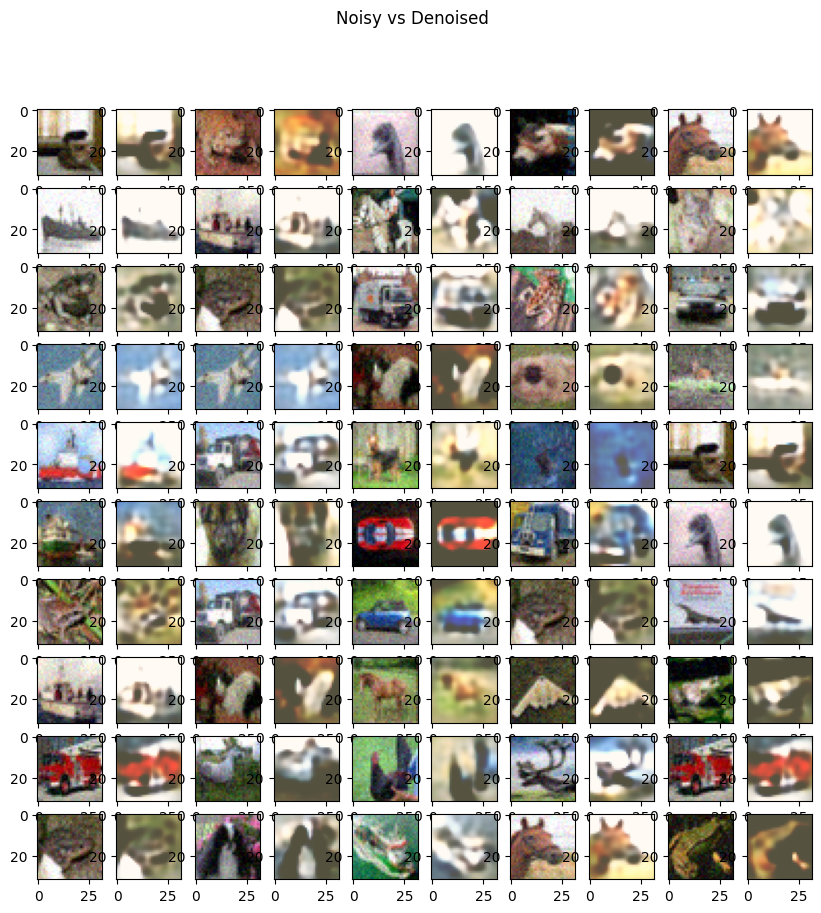

In [63]:
_imgs = image_format(model(X_test[:100].to(device)))

_idx = np.random.randint(100,size=50)

plt.figure(figsize=(10,10))
for _imgid,_id in zip(_idx,range(50)):
    plt.subplot(10,10,2*_id+1)    
    plt.imshow(image_format(X_test_noisy[_imgid].reshape(1,3,32,32))[0])

    plt.subplot(10,10,2*_id+1+1)
    plt.imshow(_imgs[_imgid]/_imgs[_imgid].max())

plt.suptitle("Noisy vs Denoised")
plt.show()